# 02 - Data Understanding
**CRISP-DM phase:** Data Understanding

This notebook establishes what the raw data contains and whether it can answer the research questions, before any modelling:

* **Part A - Sources:** what was collected, how large it is, how the tables fit together.
* **Part B - Crash data (CRSS):** outcomes, survey design and the factors associated with injury and serious injury, with statistical tests.
* **Part C - Complaints:** volumes, trends, components and the language of serious complaints, with statistical tests.
* **Part D - Linking the two:** how well the datasets match, and what the link reveals.

The full analyses are in `src/audit_raw_data.py`, `src/eda_crss.py` and `src/eda_complaints.py`; this notebook loads and explains their results. Raw files are never modified.

## 2.0 Setup

In [1]:
from pathlib import Path
import json, sys

import numpy as np
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from project_paths import CRSS_YEARS, FIGURE_DIR, TABLE_DIR, crss_extracted_dir

pd.set_option("display.max_columns", 30, "display.width", 200, "display.precision", 4)
table = lambda name, **kw: pd.read_csv(TABLE_DIR / name, **kw)

# Part A - Sources

## 2.1 What was collected
* **CRSS 2020-2024:** NHTSA's Crash Report Sampling System, a nationally representative probability sample of police-reported crashes. Five annual releases of 28 related CSV tables each, documented in the CRSS Analytical User's Manual and annual Coding and Validation Manuals.
* **Vehicle Owner Complaints:** every safety complaint submitted to NHTSA's Office of Defects Investigation since 1995, as one tab-delimited file with 51 documented fields, including the free-text narrative.

Every file was read in full, counted and fingerprinted (SHA-256), so later steps can prove they used the same data.

In [2]:
inv = table("crss_raw_file_inventory.csv")
display(inv.groupby("year").agg(tables=("table", "size"), rows_all_tables=("rows", "sum"),
                                size_GB=("size_bytes", lambda b: round(b.sum() / 1e9, 2))))
audit = json.loads((TABLE_DIR / "complaint_raw_file_audit.json").read_text())
pd.Series({k: audit[k] for k in ["rows", "documented_columns", "observed_row_widths", "unique_odino",
                                 "repeated_component_rows", "blank_narratives", "size_bytes"]}, name="complaint file").to_frame()

,tables,rows_all_tables,size_GB
year,,,
2020,28,1987672,0.74
2021,28,1989565,0.75
2022,28,1969763,0.74
2023,28,1814963,0.68
2024,28,1876428,0.71


,complaint file
rows,2250304
documented_columns,51
observed_row_widths,{'51': 2250304}
unique_odino,1622118
repeated_component_rows,628186
blank_narratives,39
size_bytes,1605264894


**Interpretation.** CRSS totals about 9.6 million rows and 3.6 GB across five years; the complaint file has 2,250,304 rows (1.6 GB) describing 1,622,118 distinct complaints. Together they are large, real and fully documented, in two different forms: structured relational tables and free-text narratives.

> **Initial plan:** read the complaint file with standard CSV parsing.
> **What we found:** the first audit counted 2,249,110 rows and two "malformed" records. The file is unquoted, and a `"` inside some narratives made the parser merge neighbouring records.
> **Decision:** read with quoting disabled. All 2,250,304 rows then have exactly the 51 documented fields, and the unchanged file fingerprint confirms the data itself was never at fault. Notebook 03 (step 3.9) reproduces the problem.

## 2.2 How the CRSS tables fit together
Tables have different **grains**: `accident` has one row per crash, `vehicle` one per vehicle, `person` one per person, and other tables list several items per vehicle or person. Joining them directly would multiply crashes, so notebook 03 summarises everything to one row per crash. Field definitions must also be consistent across the five years.

In [3]:
core = inv[inv.table.isin(["accident", "vehicle", "person"])]
display(core.pivot(index="year", columns="table", values="rows"))

def headers(year, name):
    return set(pd.read_csv(crss_extracted_dir(year) / f"{name}.csv", nrows=0).columns)
rows = []
for name in ["accident", "vehicle", "person"]:
    sets = {y: headers(y, name) for y in CRSS_YEARS}
    union, common = set.union(*sets.values()), set.intersection(*sets.values())
    rows.append({"table": name, "fields in every year": len(common), "fields in some years only": len(union - common)})
pd.DataFrame(rows)

table,accident,person,vehicle
year,,,
2020,54745,131962,94718
2021,54200,133734,95785
2022,53955,132175,94756
2023,50103,122388,87461
2024,51658,126159,90641


,table,fields in every year,fields in some years only
0,accident,80,0
1,vehicle,163,10
2,person,108,4


**Interpretation.** Each year has about 50,000-55,000 sampled crashes, 90,000 vehicles and 125,000 people. Most fields appear in every year. Differences are mostly capitalisation (e.g. `V_Config` vs `V_CONFIG`) or fields NHTSA added later, which are left missing in earlier years rather than invented. One genuine rename was found: the 2020 weather table calls its code `WEATHERCode`; notebook 03 harmonises it to `WEATHER`.

# Part B - Crash data (CRSS)

## 2.3 Crash outcomes
`MAX_SEV` records the most severe injury in each crash on the KABCO scale: **K** fatal, **A** suspected serious, **B** suspected minor, **C** possible, **O** no apparent injury.

In [4]:
sev = []
for y in CRSS_YEARS:
    a = pd.read_csv(crss_extracted_dir(y) / "accident.csv", usecols=["MAX_SEVNAME"], keep_default_na=False)
    sev.append(a.MAX_SEVNAME.value_counts(normalize=True).rename(y))
(pd.concat(sev, axis=1) * 100).round(1)

,2020,2021,2022,2023,2024
MAX_SEVNAME,,,,,
No Apparent Injury (O),44.2,46.0,48.1,47.6,47.9
Possible Injury (C),22.2,22.0,20.6,19.9,19.6
Suspected Minor Injury (B),17.4,17.2,16.1,17.2,17.8
Suspected Serious Injury (A),11.5,10.7,10.7,11.0,10.6
Fatal Injury (K),2.5,2.2,2.4,2.3,2.1
Unknown/Not Reported,1.9,1.7,1.8,1.8,1.7
"Injured, Severity Unknown",0.3,0.2,0.2,0.2,0.2
No person involved,0.0,0.0,0.0,0.0,0.0
Died Prior to Crash*,0.0,0.0,0.0,0.0,0.0


**Interpretation.** About 45-48% of sampled crashes have no apparent injury, about 20% possible injury, 17% minor, 11% serious and 2-2.5% fatal. This supports two targets: **S1** any injury vs none, and **S2** serious or fatal (A or K, about 13%) vs the rest.

## 2.4 The sample is not the nation
CRSS deliberately over-samples more severe crashes so they can be studied, and gives every crash a **weight**: how many real crashes it represents. Comparing raw sample rates with weighted national estimates shows how large this effect is.

sample_rate           weighted_national_rate          
target    y_injury y_serious               y_injury y_serious
year                                                         
2020         0.549     0.143                  0.290     0.032
2021         0.532     0.131                  0.283     0.031
2022         0.510     0.134                  0.279     0.031
2023         0.515     0.135                  0.273     0.030
2024         0.513     0.130                  0.271     0.030

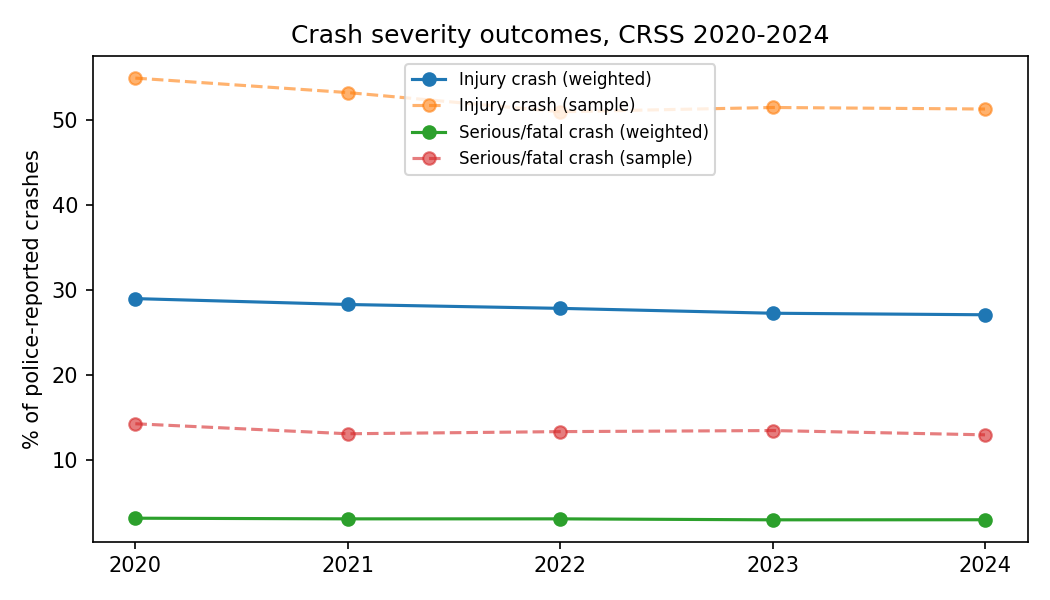

In [5]:
prev = table("eda_crss_prevalence.csv")
display(prev.pivot(index="year", columns="target", values=["sample_rate", "weighted_national_rate"]).round(3))
display(Image(filename=str(FIGURE_DIR / "eda_crss_prevalence.png"), width=650))

**Interpretation.** In the sample about **51%** of crashes involve injury and **13%** are serious or fatal; nationally the estimates are about **28%** and **3%**. The models learn from the sample, so their probabilities describe the sample, not the nation. Any national statement must use the weights (notebook 05, step 5.5). This is one of the most important facts about CRSS for interpreting the results.

## 2.5 Are outcomes stable across years?
A **chi-square test** checks whether the injury rate differs between years; **Cramér's V** measures how large any difference is (0 = none, 1 = complete).

In [6]:
tests = json.loads((TABLE_DIR / "eda_crss_tests.json").read_text())
pd.DataFrame({k: tests[k] for k in ["year_vs_y_injury", "year_vs_y_serious"]}).T

,cramers_v,p_value
year_vs_y_injury,0.0302,3.0894e-50
year_vs_y_serious,0.0135,1.4000e-09


**Interpretation.** With over 260,000 crashes even tiny differences are statistically significant (p < 0.001), but the effect sizes are negligible (Cramér's V 0.03 and 0.01). Outcomes are stable enough that training on 2020-2022 and testing on 2024 is a fair test.

## 2.6 Which crash circumstances are associated with injury?
For every crash-level coded field, a chi-square test and Cramér's V against each outcome. Fields are ranked by effect size, not p-value, because almost everything is "significant" at this sample size.

In [7]:
cv = table("eda_crss_cramers_v.csv")
names = {"EVENT1_IM": "first harmful event", "MANCOL_IM": "manner of collision", "REGION": "US region",
         "RELJCT2_IM": "relation to junction", "REL_ROAD": "location relative to road", "ALCHL_IM": "alcohol involved",
         "TYP_INT": "intersection type", "LGTCON_IM": "light condition", "HOUR_IM": "hour", "WEATHR_IM": "weather",
         "INT_HWY": "interstate", "URBANICITY": "urban/rural", "WRK_ZONE": "work zone", "MONTH": "month",
         "WKDY_IM": "day of week", "RELJCT1_IM": "within interchange area", "SCH_BUS": "school bus involved"}
cv["meaning"] = cv.field.map(names)
for t in ["y_injury", "y_serious"]:
    print(t); display(cv[cv.target == t].head(8)[["field", "meaning", "cramers_v", "p_value"]])

y_injury


,field,meaning,cramers_v,p_value
0,EVENT1_IM,first harmful event,0.3440,0.0000e+00
1,MANCOL_IM,manner of collision,0.2637,0.0000e+00
2,REGION,US region,0.1051,0.0000e+00
3,RELJCT2_IM,relation to junction,0.1017,0.0000e+00
4,REL_ROAD,location relative to road,0.1008,0.0000e+00
5,ALCHL_IM,alcohol involved,0.0909,2.0846e-289
6,TYP_INT,intersection type,0.0726,7.1490e-179
7,LGTCON_IM,light condition,0.0608,1.6221e-124


y_serious


,field,meaning,cramers_v,p_value
17,EVENT1_IM,first harmful event,0.2162,0.0000e+00
18,MANCOL_IM,manner of collision,0.2148,0.0000e+00
19,ALCHL_IM,alcohol involved,0.1566,0.0000e+00
20,REL_ROAD,location relative to road,0.1551,0.0000e+00
21,LGTCON_IM,light condition,0.1225,0.0000e+00
22,RELJCT2_IM,relation to junction,0.1110,0.0000e+00
23,HOUR_IM,hour,0.1107,0.0000e+00
24,WKDY_IM,day of week,0.0695,3.1383e-163


**Interpretation.** **What the vehicle first struck** (Cramér's V 0.34 for injury) and **how vehicles collided** (0.26) are by far the strongest crash-level associations: injury rates differ greatly between, for example, striking a pedestrian and striking a parked car. For serious or fatal crashes, **alcohol** (0.16), **location relative to the road** (0.16, e.g. leaving the roadway), **light condition** (0.12) and **hour of day** (0.11) rise in importance: they matter more for *how bad* a crash is than for *whether* anyone is hurt.

## 2.7 Speed, age and vehicle age
**Mann-Whitney U tests** compare the distributions of numeric fields between crashes with and without the outcome (suitable for skewed data such as speed). The **rank-biserial** correlation is the effect size (-1 to 1).

In [8]:
table("eda_crss_mannwhitney.csv")[["feature", "target", "median_positive", "median_negative", "rank_biserial", "p_value", "n"]]

,feature,target,median_positive,median_negative,rank_biserial,p_value,n
0,person.AGE_IM__min,y_injury,25.0,26.0,0.0431,2.5504e-50,159920
1,person.AGE_IM__min,y_serious,27.0,25.0,-0.0455,3.5705e-27,159516
2,person.AGE_IM__max,y_injury,50.0,48.0,-0.0359,1.8370e-35,159920
3,person.AGE_IM__max,y_serious,48.0,49.0,0.0197,3.1190e-06,159516
4,vehicle.TRAV_SP__max,y_injury,35.0,20.0,-0.1768,0.0000e+00,84769
5,vehicle.TRAV_SP__max,y_serious,45.0,25.0,-0.3994,0.0000e+00,84552
6,vehicle.VSPD_LIM__max,y_injury,40.0,40.0,-0.0156,3.6936e-07,138406
7,vehicle.VSPD_LIM__max,y_serious,45.0,40.0,-0.1530,1.8800e-259,138047
8,vehicle.MDLYR_IM__min,y_injury,2009.0,2010.0,0.0322,8.7555e-29,159920
9,vehicle.MDLYR_IM__min,y_serious,2008.0,2010.0,0.1154,2.3426e-165,159516


**Interpretation.** **Travel speed** has the largest effect: the median highest speed is 45 mph in serious or fatal crashes vs 25 mph in others (rank-biserial -0.40), and 35 vs 20 mph for injury vs no injury. Serious crashes also involve **older vehicles** (median oldest model year 2008 vs 2010), consistent with newer cars' added safety equipment. Driver and occupant age differences are statistically significant but small.

## 2.8 Do recorded vehicle defects make crashes worse?
Police can record a vehicle defect as a contributing factor (tyres, brakes, steering and so on). This links crashes to the complaint data's subject: defective components.

In [9]:
pd.DataFrame({k.replace("vehicle_defect_vs_", ""): v for k, v in tests.items() if k.startswith("vehicle_defect")}).T

,rate_with_defect,rate_without_defect,crashes_with_defect,chi2_p
y_injury,0.5388,0.5237,6923.0,0.0139
y_serious,0.1497,0.1343,6908.0,0.0002


**Interpretation.** About 6,900 crashes (2.6%) have a recorded vehicle defect. They are **about 12% more likely to be serious or fatal** (15.0% vs 13.4%, chi-square p = 0.0002), but only marginally more likely to involve any injury (53.9% vs 52.4%, p = 0.014). Defects matter more for severity than for whether injury occurs. They are too rare to predict as a target in their own right (notebook 04).

## 2.9 Screening every feature, and a leakage check
After notebook 03 builds the crash-level features, each one is tested alone: how well does that single feature separate the outcome (ROC-AUC; 0.5 = no information)? This shows the strongest individual signals and checks for **leakage**: a legitimate field should never predict the outcome almost perfectly on its own.

Strongest single-feature ROC-AUC: {'y_injury': 0.681, 'y_serious': 0.721}


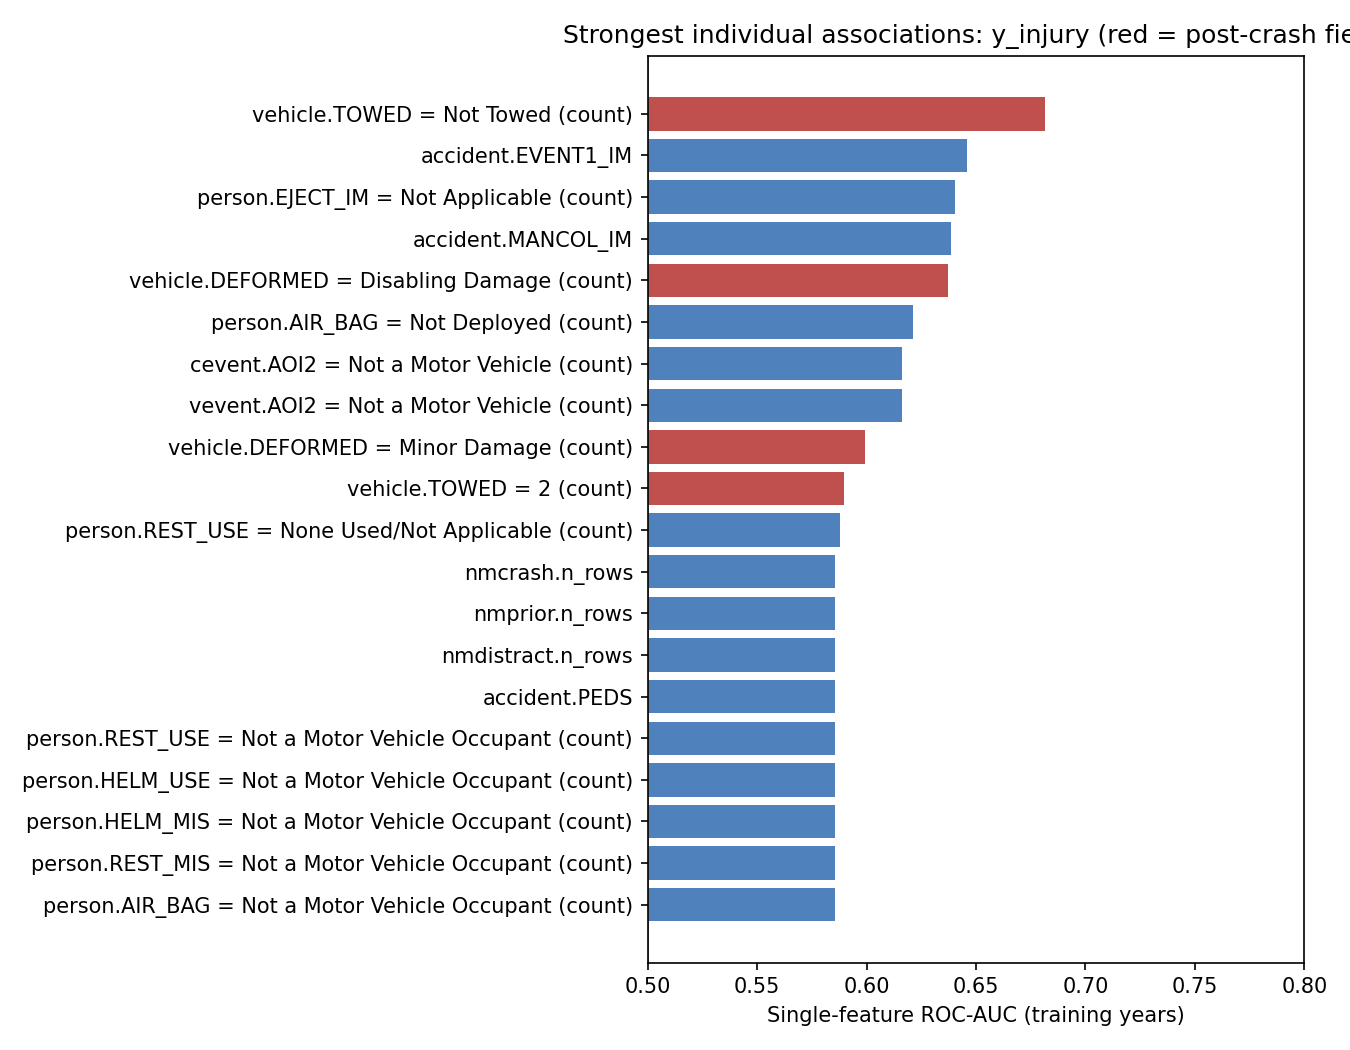

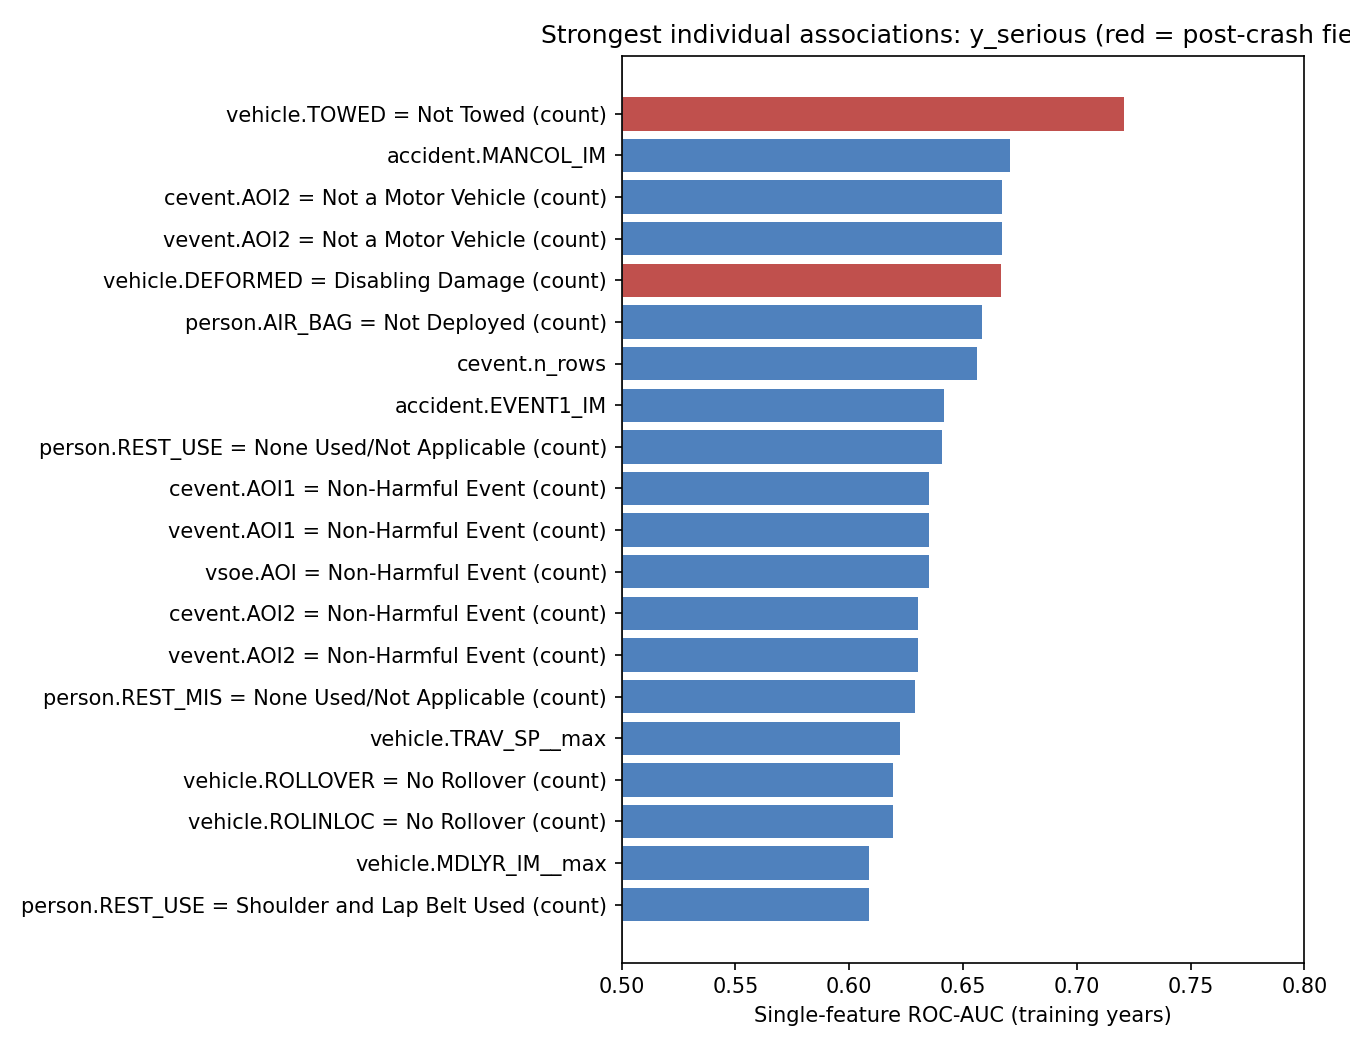

In [10]:
print("Strongest single-feature ROC-AUC:", {k: round(v, 3) for k, v in tests["leakage_check_max_single_feature_auc"].items()})
for t in ["y_injury", "y_serious"]:
    display(Image(filename=str(FIGURE_DIR / f"eda_crss_top_{t}.png"), width=700))

**Interpretation.** No single feature exceeds a ROC-AUC of 0.72, so no single input hands the model the answer. This is one leakage check, not proof that there is none; the others are the excluded-field register (notebook 03), removal of post-crash fields (notebook 04) and the chronological split. The strongest individual signals are vehicle towing and damage (post-crash fields, shown in red), the number of people not inside an enclosed vehicle (pedestrians, cyclists, motorcyclists), the first harmful event, restraint use and travel speed. Good prediction must therefore come from **combining** many moderate signals, which is what the models in notebook 04 do.

# Part C - Owner complaints

## 2.10 Volume and seriousness over time

,complaints,serious_rate,crash_rate,fire_rate,injury_rate
year,,,,,
2010,65149,0.103,0.075,0.022,0.038
2011,48986,0.076,0.044,0.024,0.028
2012,41505,0.089,0.051,0.030,0.033
2013,50045,0.078,0.048,0.021,0.030
2014,76997,0.089,0.063,0.019,0.038
2015,74692,0.084,0.056,0.022,0.037
2016,70868,0.077,0.052,0.020,0.034
2017,67698,0.075,0.050,0.020,0.032
2018,64711,0.081,0.050,0.024,0.033


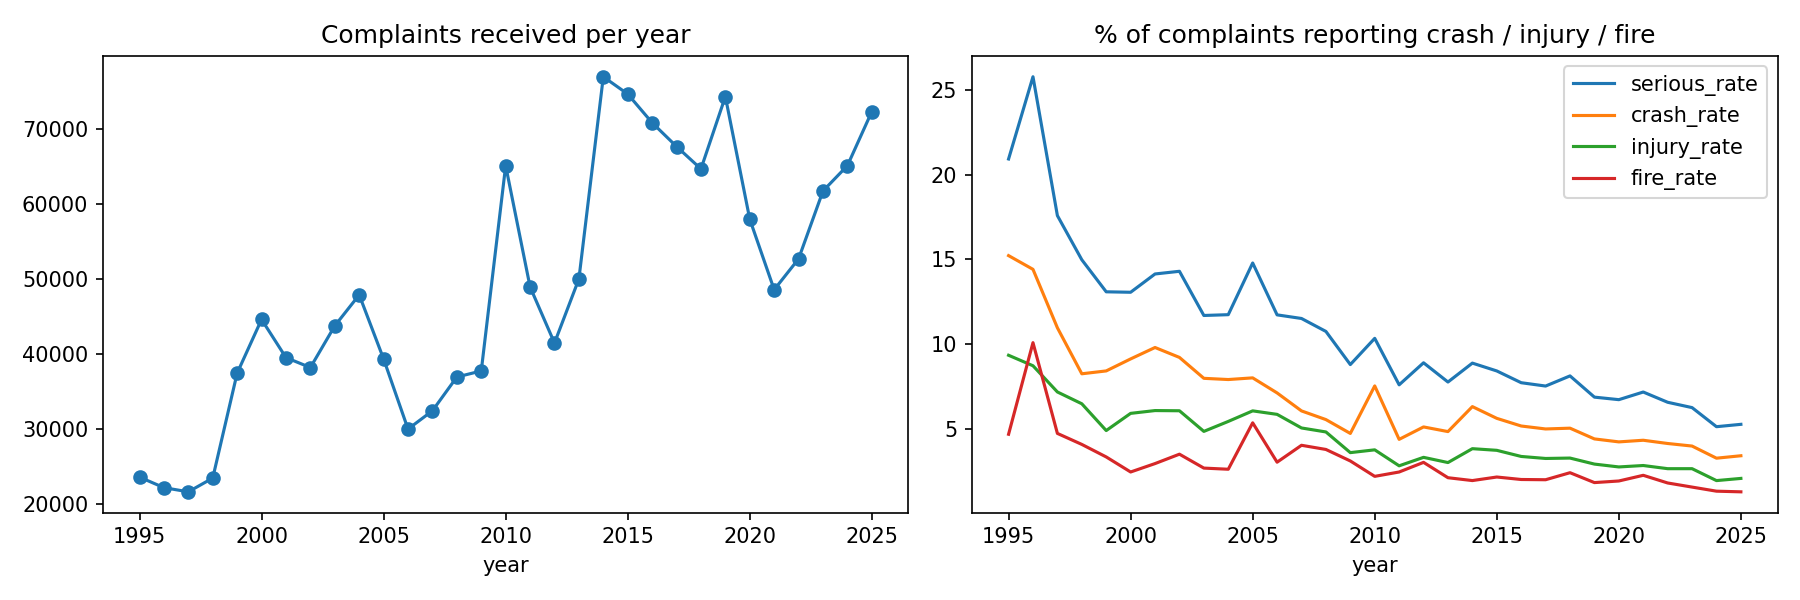

Trend in serious-incident share since 2010 (Kendall's tau): {'kendall_tau': -0.75, 'p_value': 3.7189e-06}


In [11]:
yearly = table("eda_complaints_yearly.csv", index_col=0)
display(yearly.loc[2010:].round(3))
display(Image(filename=str(FIGURE_DIR / "eda_complaints_yearly.png"), width=800))
ctests = json.loads((TABLE_DIR / "eda_complaints_tests.json").read_text())
print("Trend in serious-incident share since 2010 (Kendall's tau):", ctests["serious_rate_trend_2010_on"])

**Interpretation.** NHTSA receives roughly 50,000-77,000 complaints a year. The share describing a crash, fire, injury or death has **fallen steadily** since 2010 (Kendall's tau -0.75, p < 0.001), from about 8-10% in the early 2010s to about 5-6% in recent years. **Kendall's tau** measures how consistently a series rises or falls (-1 to 1). The drift matters for modelling: the serious-incident model is trained on older years with a higher rate and tested on recent ones.

## 2.11 Which components owners complain about, and how that is changing

,kendall_tau,p_value,share_2010,share_latest
SPEED CONTROL,-0.735,0.000,0.114,0.036
STRUCTURE,-0.735,0.000,0.066,0.047
LIGHTING,-0.662,0.000,0.043,0.026
SUSPENSION,-0.574,0.001,0.051,0.031
TIRES,-0.515,0.003,0.023,0.008
LATCHES/LOCKS,-0.500,0.005,0.027,0.005
EQUIPMENT,-0.441,0.013,0.023,0.003
SEATS,-0.353,0.052,0.017,0.018
VISIBILITY,-0.338,0.063,0.053,0.031
STEERING,-0.309,0.091,0.107,0.074


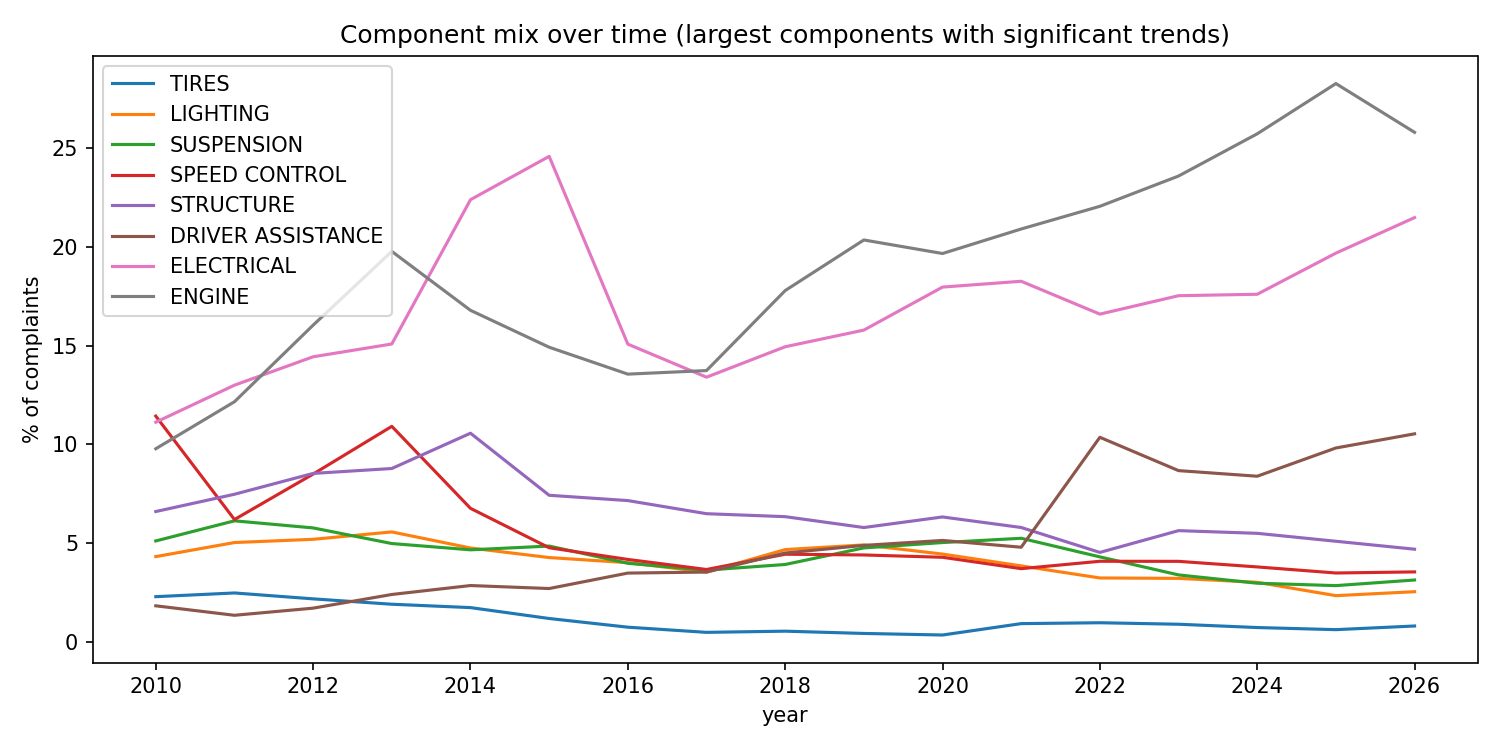

In [12]:
trend = table("eda_complaints_component_trends.csv", index_col=0)
display(trend.round(3))
display(Image(filename=str(FIGURE_DIR / "eda_complaints_component_mix.png"), width=800))

**Interpretation.** The mix has shifted strongly. **Driver-assistance** complaints (forward-collision avoidance, lane departure, stability control) rose from about **2% to 10.5%** of complaints (tau 0.87), **engine** from 10% to 26% and **electrical** from 11% to 21%; **speed control** fell from 11% to 4%. The complaints reflect the technology on the road, which is why the text models are trained on 2010 onwards and need periodic retraining.

## 2.12 Which components carry more serious incidents?
For each component, the share of its complaints reporting a crash, fire, injury or death, compared with all other complaints (relative risk), tested with chi-square.

In [13]:
table("eda_complaints_component_severity.csv").round(3)

,component,complaints,serious_rate_if_component,serious_rate_otherwise,chi2_p,relative_risk
0,AIR BAGS,114780,0.187,0.060,0.00,3.117
1,SPEED CONTROL,55889,0.171,0.068,0.00,2.495
2,SEAT BELTS,16757,0.160,0.072,0.00,2.209
3,SEATS,16081,0.155,0.073,0.00,2.141
4,BRAKES,101971,0.117,0.069,0.00,1.693
5,STRUCTURE,69820,0.095,0.072,0.00,1.320
6,EQUIPMENT,7095,0.095,0.074,0.00,1.291
7,WHEELS,17358,0.088,0.074,0.00,1.201
8,DRIVER ASSISTANCE,54199,0.084,0.073,0.00,1.142
9,ELECTRICAL,180739,0.074,0.074,0.59,0.995


**Interpretation.** **Air-bag** complaints are 3.1 times as likely as other complaints to describe a crash, injury, fire or death; **speed control** 2.5 times, **seat belts** 2.2, **seats** 2.1 and **brakes** 1.7 times. Visibility, latches, power train and fuel-system complaints are about half as likely. This tells an analyst where serious complaints concentrate.

## 2.13 How serious complaints are written

In [14]:
print("Narrative length, serious vs not (Mann-Whitney):", ctests["narrative_words_serious_vs_not"])
table("eda_complaints_serious_terms.csv").head(20)

Narrative length, serious vs not (Mann-Whitney): {'median_serious': 96.0, 'median_not': 79.0, 'rank_biserial': -0.1559720887, 'p_value': 0.0}


,term,z,count_in_class
0,report,109.3207,4279
1,police,101.8558,4213
2,filed,99.5130,3534
3,injuries,98.5607,3755
4,deploy,97.9751,3434
5,hit,80.1720,3788
6,crashed,78.9411,2818
7,smoke,78.6188,2291
8,deployed,76.9888,2131
9,attention,65.5067,1578


**Interpretation.** Serious complaints are longer (median 96 vs 79 words). The words most over-represented in them, ranked by a **log-odds z-score** (how much more often a term appears in serious than in other complaints, allowing for its overall frequency), describe what happened: *police report, injuries, deployed, crashed, smoke, destroyed, impact, insurance*. This shows the narrative text carries a strong signal for the serious-incident model (U2).

# Part D - Linking the two datasets

## 2.14 How well do the datasets match?
Both datasets record make, model and model year. After normalising names (e.g. "MERCEDES-BENZ" and "MERCEDESBENZ"), the share of CRSS crash vehicles whose make + model + year also appears in the complaints shows whether a link is meaningful.

In [15]:
feas = json.loads((TABLE_DIR / "feasibility_summary.json").read_text())
pd.Series(feas["linkage"]).to_frame("value")

,value
crss_vehicles_with_valid_model_year,440122.0000
crss_vehicle_share_matching_complaint_make_model_year,0.8009
distinct_make_model_year_in_both,7223.0000


**Interpretation.** **80% of CRSS crash vehicles** match a make + model + year that also has complaints, across 7,223 shared vehicle types. The link is broad enough to support the integrated analysis. It is a link between groups of vehicles, not between individual crashes and complaints, which never share an identifier.

## 2.15 Complaints adjusted for exposure
CRSS weights estimate how many vehicles of each make and model year were in police-reported crashes nationally, used here as a proxy for exposure (it is not a count of vehicles on the road). Dividing complaint counts by this exposure gives a fair comparison between popular and rare vehicles.

**How the two datasets are linked.** There is no shared key, so they are matched on make, model and model year. On both sides make and model are put into the same form (upper case, letters and digits only, so "F-150" and "F150" match) and then joined. CRSS gives make and model as names decoded from the VIN (`VPICMAKENAME`, `VPICMODELNAME`); the complaint file gives them as NHTSA recorded them (`MAKETXT`, `MODELTXT`). No individual complaint is ever matched to an individual crash.

Spearman correlation, exposure vs complaints: 0.808 | make/model-year cells: 852 | 90th / 10th percentile complaint rate: 25.8


,complaints,exposure,complaints_per_10k
mk,,,
RAM,10431,758817.7,137.5
SUBARU,10840,836893.8,129.5
KIA,16709,1688649.3,98.9
JEEP,16870,1752162.8,96.3
AUDI,2884,300058.3,96.1
HYUNDAI,18949,2087918.3,90.8
MITSUBISHI,962,343301.5,28.0
TOYOTA,15387,5988434.7,25.7
LEXUS,1715,761583.5,22.5


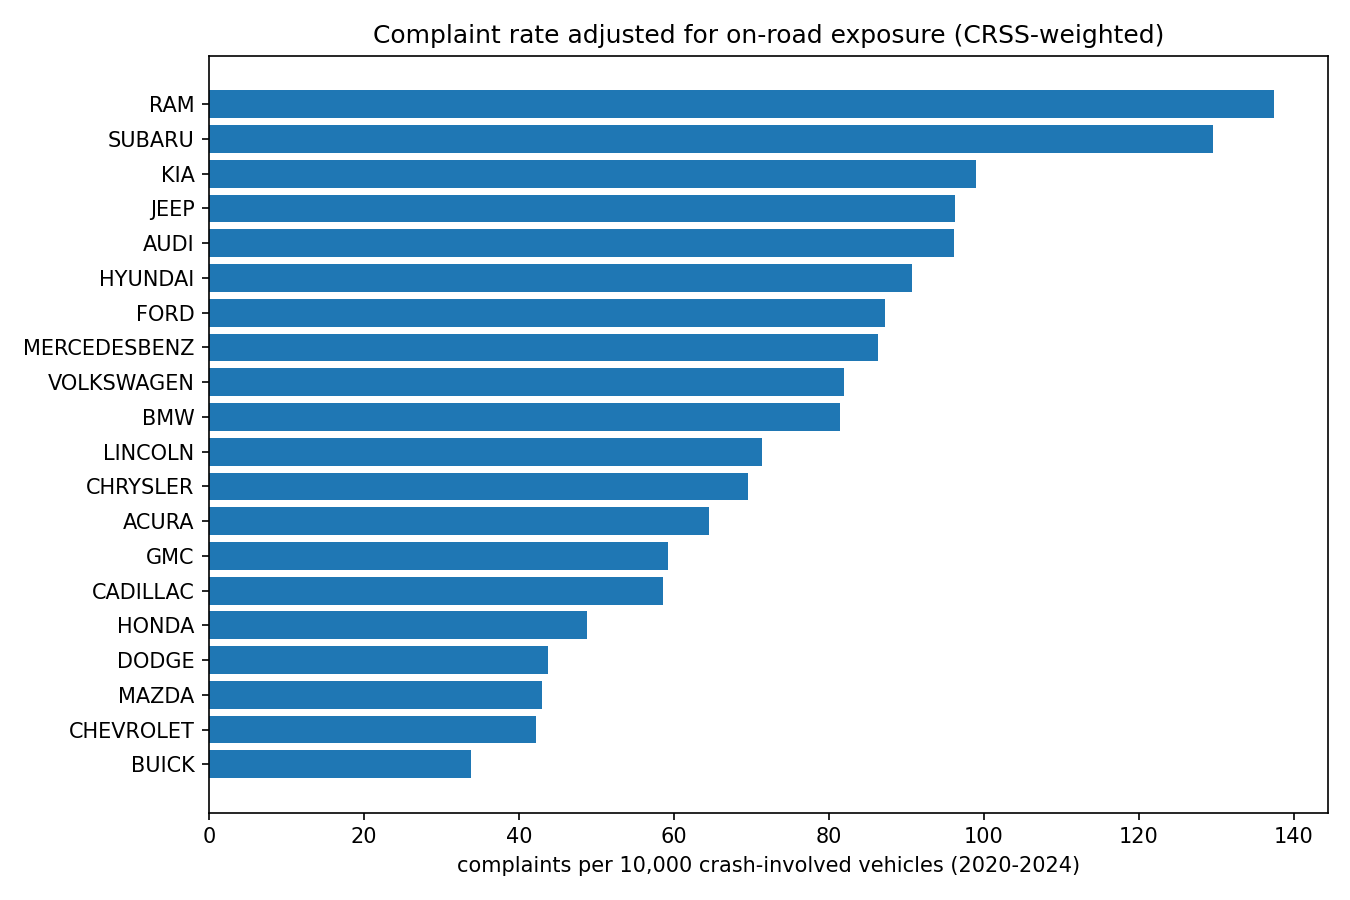

In [16]:
print("Spearman correlation, exposure vs complaints:", round(ctests["linkage"]["spearman_exposure_vs_complaints"], 3),
      "| make/model-year cells:", ctests["linkage"]["make_modelyear_cells"],
      "| 90th / 10th percentile complaint rate:", round(ctests["linkage"]["complaint_rate_p90_over_p10"], 1))
make = table("eda_linkage_make.csv", index_col=0).round(1)
display(pd.concat([make.head(6), make.tail(4)]))
display(Image(filename=str(FIGURE_DIR / "eda_linkage_make.png"), width=700))

**Interpretation.** Exposure strongly explains complaint volume (Spearman 0.81): popular vehicles get more complaints mainly because there are more of them. After adjusting, vehicles still differ enormously: the 90th-percentile make/model-year has **26 times** the complaint rate of the 10th. By make, RAM (137 per 10,000 crash-involved vehicles) and Subaru (130) rank highest and Toyota (26) and Lexus (23) among the lowest, a very different picture from raw counts, where Ford and Chevrolet lead simply through volume. **Neither dataset alone can produce this comparison**; it is the core of the integrated application (notebook 06).

## 2.16 Summary of findings and hand-off
| Finding | Consequence for later phases |
|---|---|
| CRSS over-samples severe crashes (51% vs 28% injury nationally) | Model probabilities describe the sample; national figures use weights |
| What was struck, collision type, speed, alcohol and darkness drive severity | Expected to dominate the crash models; all fields still offered to the benchmark models |
| Recorded defects raise serious-crash risk by about 12% but are rare | Defects analysed here, not used as a model target |
| No single feature gives the outcome away (max AUC 0.72) | One leakage check passed; outcome fields are still excluded by rule and post-crash fields reviewed in notebook 04 |
| Complaint mix and seriousness drift over time | Chronological splits; text models trained from 2010; retraining plan |
| Air bags, speed control and seat belts carry the most serious complaints | Useful context for triage and the U2 model |
| 80% of crash vehicles link to complaint vehicles | Complaints per crash-involved vehicle (RQ5) is feasible |

Notebook 03 builds the modelling tables from these findings.